In [1]:
import pandas as pd

df = pd.read_csv('../data/obesity_level.csv')

print("Filas y columnas:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

df.head()

Filas y columnas: (20758, 18)

Columnas:
['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', '0be1dad']


,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,0be1dad
0,0,Male,24.443011,1.699998,81.669950,1,1,2.000000,2.983297,Sometimes,0,2.763573,0,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,1,1,2.000000,3.000000,Frequently,0,2.000000,0,1.000000,1.000000,0,Automobile,0rmal_Weight
2,2,Female,18.000000,1.711460,50.165754,1,1,1.880534,1.411685,Sometimes,0,1.910378,0,0.866045,1.673584,0,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,1,1,3.000000,3.000000,Sometimes,0,1.674061,0,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,1,1,2.679664,1.971472,Sometimes,0,1.979848,0,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [2]:
print("Column names and data types:")
print(df.dtypes)

print("\nNull values per column:")
print(df.isnull().sum())

print("\nGender distribution:")
print(df['Gender'].value_counts())

Column names and data types:
id                                  int64
Gender                                str
Age                               float64
Height                            float64
Weight                            float64
family_history_with_overweight      int64
FAVC                                int64
FCVC                              float64
NCP                               float64
CAEC                                  str
SMOKE                               int64
CH2O                              float64
SCC                                 int64
FAF                               float64
TUE                               float64
CALC                                  str
MTRANS                                str
0be1dad                               str
dtype: object

Null values per column:
id                                0
Gender                            0
Age                               0
Height                            0
Weight                          

In [4]:
print("Exact column names:")
print(df.columns.tolist())

print("\nTarget variable unique values:")
print(df['0be1dad'].value_counts())

Exact column names:
['id', 'Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', '0be1dad']

Target variable unique values:
0be1dad
Obesity_Type_III       4046
Obesity_Type_II        3248
0rmal_Weight           3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64


In [5]:
for col in ['Gender', 'CAEC', 'CALC', 'MTRANS']:
    print(f"\n{col}:")
    print(df[col].unique())


Gender:
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

CAEC:
<StringArray>
['Sometimes', 'Frequently', '0', 'Always']
Length: 4, dtype: str

CALC:
<StringArray>
['Sometimes', '0', 'Frequently']
Length: 3, dtype: str

MTRANS:
<StringArray>
['Public_Transportation', 'Automobile', 'Walking', 'Motorbike', 'Bike']
Length: 5, dtype: str


In [6]:
df = df.rename(columns={'0be1dad': 'NObeyesdad'})
df['NObeyesdad'] = df['NObeyesdad'].replace('0rmal_Weight', 'Normal_Weight')
df['CAEC'] = df['CAEC'].replace('0', 'No')
df['CALC'] = df['CALC'].replace('0', 'No')

print(df['NObeyesdad'].value_counts())
print(df['CAEC'].value_counts())
print(df['CALC'].value_counts())

NObeyesdad
Obesity_Type_III       4046
Obesity_Type_II        3248
Normal_Weight          3082
Obesity_Type_I         2910
Insufficient_Weight    2523
Overweight_Level_II    2522
Overweight_Level_I     2427
Name: count, dtype: int64
CAEC
Sometimes     17529
Frequently     2472
Always          478
No              279
Name: count, dtype: int64
CALC
Sometimes     15066
No             5163
Frequently      529
Name: count, dtype: int64


## Data Quality Finding: Corrupted "No"/"Yes" Text Replacement

While exploring the target variable, an unexpected value `0be1dad` appeared 
instead of the expected column name `NObeyesdad`, along with a category 
value `0rmal_Weight` instead of `Normal_Weight`.

Investigation revealed a systematic pattern: the substrings "No" and "Yes" 
had been globally replaced with "0" and "1" somewhere upstream in this 
dataset's distribution — likely an automated cleaning step that didn't 
account for these substrings appearing inside other words (e.g., "**No**rmal" 
and "N**O**be**yes**dad" both contain "No"/"yes" and were affected twice in 
the same word).

This same pattern explains why binary columns like `family_history_with_overweight`, 
`FAVC`, `SMOKE`, and `SCC` appear as 0/1 instead of "No"/"Yes" — a fortunate 
side effect that actually left them in a usable numeric format. However, 
`CAEC`, `CALC`, and the target column required manual correction:
- Renamed `0be1dad` → `NObeyesdad`
- Fixed `0rmal_Weight` → `Normal_Weight`
- Fixed stray `"0"` values in `CAEC` and `CALC` → `"No"`

This is a reminder to never assume column names or category values are 
clean, even from a well-known, widely-used public dataset.

In [7]:
df_women = df[df['Gender'] == 'Female'].copy()

print("Total women:", len(df_women))
print("\nWeight category distribution (women only):")
print(df_women['NObeyesdad'].value_counts())

Total women: 10422

Weight category distribution (women only):
NObeyesdad
Obesity_Type_III       4041
Normal_Weight          1660
Insufficient_Weight    1621
Obesity_Type_I         1267
Overweight_Level_I     1070
Overweight_Level_II     755
Obesity_Type_II           8
Name: count, dtype: int64


In [8]:
print("Obesity_Type_II by gender:")
print(df[df['NObeyesdad'] == 'Obesity_Type_II']['Gender'].value_counts())

print("\nFull distribution by gender (crosstab):")
print(pd.crosstab(df['Gender'], df['NObeyesdad']))

Obesity_Type_II by gender:
Gender
Male      3240
Female       8
Name: count, dtype: int64

Full distribution by gender (crosstab):
NObeyesdad  Insufficient_Weight  Normal_Weight  Obesity_Type_I  \
Gender                                                           
Female                     1621           1660            1267   
Male                        902           1422            1643   

NObeyesdad  Obesity_Type_II  Obesity_Type_III  Overweight_Level_I  \
Gender                                                              
Female                    8              4041                1070   
Male                   3240                 5                1357   

NObeyesdad  Overweight_Level_II  
Gender                           
Female                      755  
Male                       1767  


## Data Quality Finding: Gender Imbalance in Obesity_Type_II

While exploring the target variable by gender, a striking pattern emerged: 
`Obesity_Type_II` is almost exclusively male (3,240 of 3,248 cases, 99.8%), 
while the adjacent category `Obesity_Type_III` is almost exclusively female 
(4,041 of 4,046 cases, 99.9%).

This is likely a consequence of this dataset's generation method — it is 
partly synthetic (built using SMOTE on a smaller real survey sample), and 
the height/weight profiles that originally defined "Obesity_Type_II" in 
the source data appear to have been predominantly male, a pattern that 
SMOTE preserved and amplified rather than correcting.

**Practical impact:** among women specifically, `Obesity_Type_II` has only 
8 cases — too few to treat as a reliable category for statistical testing 
or modeling. For the women-focused analysis in this project, these 8 cases 
are excluded, leaving **6 weight categories**: Insufficient_Weight, 
Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, 
and Obesity_Type_III.

This is disclosed here rather than silently dropped, since it reflects a 
real structural bias in the dataset worth being transparent about.

In [9]:
df_women = df[(df['Gender'] == 'Female') & (df['NObeyesdad'] != 'Obesity_Type_II')].copy()

print("Final dataset for analysis:")
print("Total women:", len(df_women))
print("\nWeight category distribution:")
print(df_women['NObeyesdad'].value_counts())

Final dataset for analysis:
Total women: 10414

Weight category distribution:
NObeyesdad
Obesity_Type_III       4041
Normal_Weight          1660
Insufficient_Weight    1621
Obesity_Type_I         1267
Overweight_Level_I     1070
Overweight_Level_II     755
Name: count, dtype: int64


In [10]:
# Order categories from lowest to highest body weight
weight_order = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 
                 'Overweight_Level_II', 'Obesity_Type_I', 'Obesity_Type_III']

behavior_summary = df_women.groupby('NObeyesdad')[['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'Age', 'Weight']].mean().round(2)
behavior_summary = behavior_summary.reindex(weight_order)

print(behavior_summary)

                     FCVC   NCP  CH2O   FAF   TUE    Age  Weight
NObeyesdad                                                      
Insufficient_Weight  2.57  2.73  1.64  1.10  0.67  19.70   47.28
Normal_Weight        2.43  2.83  1.71  1.05  0.59  20.71   56.71
Overweight_Level_I   2.28  2.38  1.92  0.87  0.52  24.01   69.53
Overweight_Level_II  2.33  2.47  1.86  0.85  0.66  26.55   75.82
Obesity_Type_I       2.11  2.23  1.91  0.66  0.56  27.43   82.61
Obesity_Type_III     3.00  3.00  2.33  0.55  0.55  24.13  117.71


In [11]:
from scipy import stats

variables_to_test = ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'Age', 'Weight']

print("ANOVA results: is there a significant difference across weight categories?\n")
for var in variables_to_test:
    groups = [df_women[df_women['NObeyesdad'] == cat][var].values for cat in weight_order]
    f_stat, p_value = stats.f_oneway(*groups)
    significance = "✅ significant" if p_value < 0.05 else "❌ not significant"
    print(f"{var}: F={f_stat:.2f}, p={p_value:.4f} → {significance}")

ANOVA results: is there a significant difference across weight categories?

FCVC: F=1310.77, p=0.0000 → ✅ significant
NCP: F=343.70, p=0.0000 → ✅ significant
CH2O: F=476.56, p=0.0000 → ✅ significant
FAF: F=170.44, p=0.0000 → ✅ significant
TUE: F=18.55, p=0.0000 → ✅ significant
Age: F=548.58, p=0.0000 → ✅ significant
Weight: F=18123.95, p=0.0000 → ✅ significant


In [12]:
def eta_squared(groups_list):
    all_values = np.concatenate(groups_list)
    grand_mean = all_values.mean()
    ss_total = sum((all_values - grand_mean)**2)
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups_list)
    return ss_between / ss_total

import numpy as np

print("Effect size (eta squared) — how much each variable actually matters:\n")
for var in variables_to_test:
    groups = [df_women[df_women['NObeyesdad'] == cat][var].values for cat in weight_order]
    eta2 = eta_squared(groups)
    print(f"{var}: η² = {eta2:.3f}")

Effect size (eta squared) — how much each variable actually matters:

FCVC: η² = 0.386
NCP: η² = 0.142
CH2O: η² = 0.186
FAF: η² = 0.076
TUE: η² = 0.009
Age: η² = 0.209
Weight: η² = 0.897


## Finding: Statistical Significance vs. Practical Effect Size

With a large sample (n=10,414), ANOVA flagged all 7 tested variables as 
statistically significant (p<0.0001) — including `TUE` (screen time), 
which showed no clear visual trend across weight categories. This is a 
well-known statistical pitfall: with large samples, even trivial 
differences become "significant," because the test is sensitive enough 
to detect tiny, real-but-meaningless patterns.

To distinguish real-world relevance from statistical noise, effect size 
(eta squared, η²) was calculated for each variable — representing the 
proportion of total variation explained by weight category:

- **Large effects:** FCVC — vegetable consumption (η²=0.386), Age (η²=0.209), 
  CH2O — water intake (η²=0.186), NCP — meals/day (η²=0.142)
- **Moderate effect:** FAF — physical activity frequency (η²=0.076)
- **Negligible effect:** TUE — screen time (η²=0.009), despite p<0.05

`Weight` itself showed the highest η² (0.897), but was excluded from the 
behavioral findings above: weight (together with height) is used to 
derive the `NObeyesdad` category directly, so this relationship is 
near-tautological rather than a genuine behavioral insight.

**Takeaway:** vegetable consumption, age, water intake, and meal frequency 
are the lifestyle factors that most meaningfully distinguish weight 
categories among women in this dataset — physical activity has a real but 
more modest effect, and screen time does not meaningfully differ across 
groups despite technical significance.

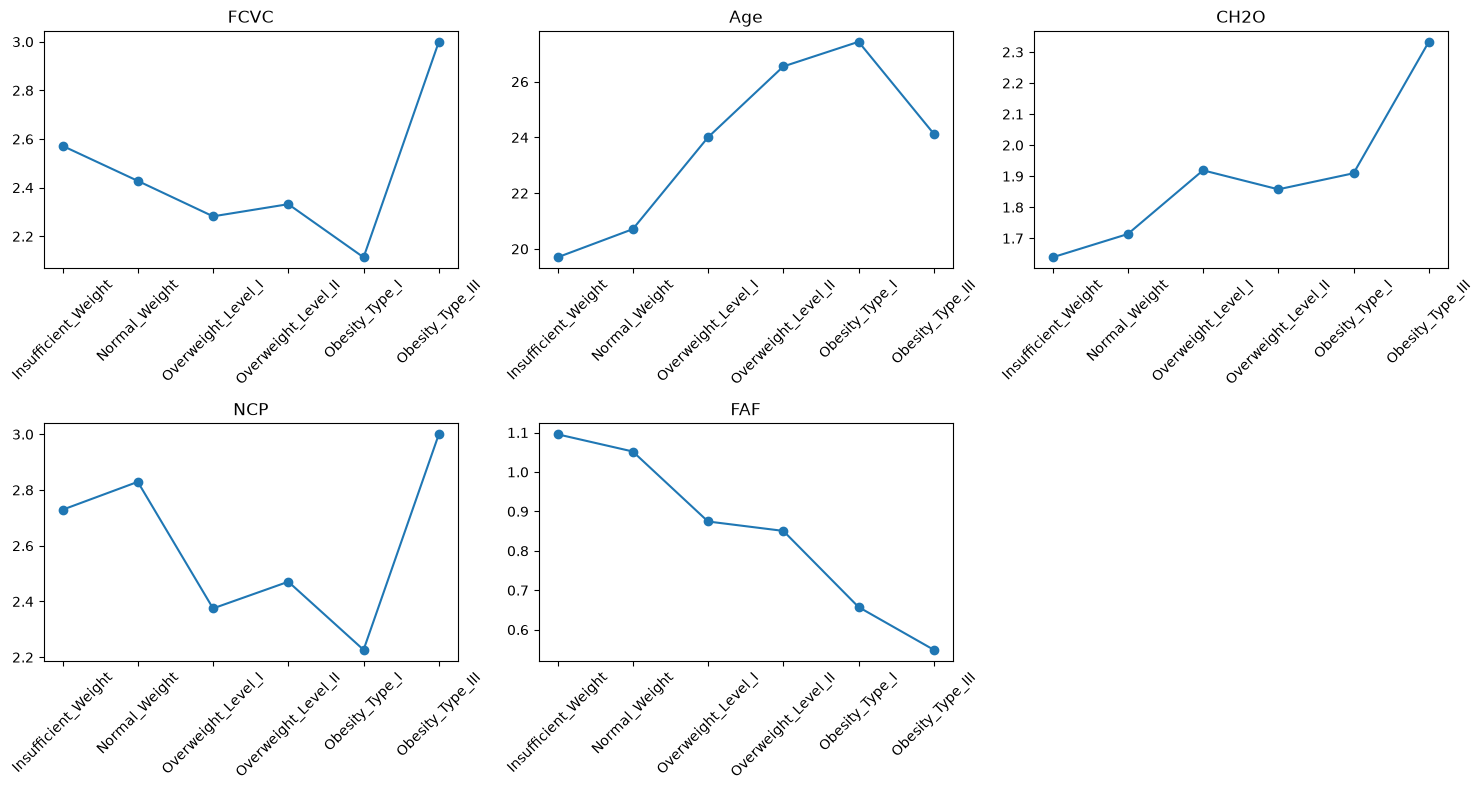

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
variables_plot = ['FCVC', 'Age', 'CH2O', 'NCP', 'FAF']

for i, var in enumerate(variables_plot):
    ax = axes[i // 3, i % 3]
    means = df_women.groupby('NObeyesdad')[var].mean().reindex(weight_order)
    ax.plot(weight_order, means.values, marker='o')
    ax.set_title(var)
    ax.tick_params(axis='x', rotation=45)

axes[1, 2].axis('off')
plt.tight_layout()
plt.show()

In [14]:
# Check the spread (not just the mean) within Obesity_Type_III
print(df_women[df_women['NObeyesdad'] == 'Obesity_Type_III'][['FCVC', 'CH2O', 'NCP', 'Age']].describe())

         FCVC         CH2O     NCP          Age
count  4041.0  4041.000000  4041.0  4041.000000
mean      3.0     2.333027     3.0    24.129020
std       0.0     0.577623     0.0     2.575603
min       3.0     1.000000     3.0    18.000000
25%       3.0     1.852692     3.0    21.572114
50%       3.0     2.618198     3.0    25.957740
75%       3.0     2.737091     3.0    26.000000
max       3.0     3.000000     3.0    30.613586


In [15]:
for cat in weight_order:
    subset = df_women[df_women['NObeyesdad'] == cat]
    print(f"\n{cat} (n={len(subset)}):")
    print(subset[['FCVC', 'NCP', 'CH2O', 'FAF', 'Age']].std().round(3))


Insufficient_Weight (n=1621):
FCVC    0.596
NCP     0.952
CH2O    0.582
FAF     0.841
Age     2.234
dtype: float64

Normal_Weight (n=1660):
FCVC    0.563
NCP     0.729
CH2O    0.567
FAF     0.878
Age     3.571
dtype: float64

Overweight_Level_I (n=1070):
FCVC    0.513
NCP     0.956
CH2O    0.632
FAF     0.784
Age     6.722
dtype: float64

Overweight_Level_II (n=755):
FCVC    0.478
NCP     0.837
CH2O    0.547
FAF     0.796
Age     7.957
dtype: float64

Obesity_Type_I (n=1267):
FCVC    0.474
NCP     0.930
CH2O    0.651
FAF     0.792
Age     8.606
dtype: float64

Obesity_Type_III (n=4041):
FCVC    0.000
NCP     0.000
CH2O    0.578
FAF     0.729
Age     2.576
dtype: float64


In [16]:
print(df_women[df_women['NObeyesdad'] == 'Obesity_Type_III'][['SMOKE', 'SCC', 'FAVC', 'Height', 'Weight']].std().round(3))

SMOKE      0.031
SCC        0.000
FAVC       0.016
Height     0.059
Weight    13.330
dtype: float64


## Data Quality Finding: Obesity_Type_III Shows Synthetic Data Artifacts

Investigating the unexpected spike in FCVC, NCP, and CH2O within 
`Obesity_Type_III` revealed zero standard deviation in `FCVC` and `NCP` 
(every one of the 4,041 women shares the exact same value), and near-zero 
variation in `SCC`, `FAVC`, `SMOKE`, and `Height`. Only `Weight`, `Age`, 
and `CH2O` show realistic variation.

This pattern — present only in this category, not in the other five — 
indicates that `Obesity_Type_III`'s synthetic generation (via SMOTE) 
produced near-duplicate records from a very small number of original 
real cases, varying weight but leaving most behavioral and demographic 
fields frozen. This makes the category unreliable for behavioral analysis.

**Decision:** `Obesity_Type_III` (4,041 cases) is excluded from the 
behavioral analysis going forward. The final working dataset covers 
**5 weight categories** and **6,373 women**.

In [17]:
df_women_clean = df_women[df_women['NObeyesdad'] != 'Obesity_Type_III'].copy()
weight_order_clean = ['Insufficient_Weight', 'Normal_Weight', 'Overweight_Level_I', 
                        'Overweight_Level_II', 'Obesity_Type_I']

print("Final clean dataset:", len(df_women_clean), "women")
print(df_women_clean['NObeyesdad'].value_counts())

Final clean dataset: 6373 women
NObeyesdad
Normal_Weight          1660
Insufficient_Weight    1621
Obesity_Type_I         1267
Overweight_Level_I     1070
Overweight_Level_II     755
Name: count, dtype: int64


In [18]:
df_women_clean['BMI_calculated'] = df_women_clean['Weight'] / (df_women_clean['Height'] ** 2)

bmi_check = df_women_clean.groupby('NObeyesdad')['BMI_calculated'].agg(['mean', 'min', 'max']).round(2)
bmi_check = bmi_check.reindex(weight_order_clean)

print(bmi_check)

                      mean    min    max
NObeyesdad                              
Insufficient_Weight  17.62  12.93  28.41
Normal_Weight        21.81  15.06  32.88
Overweight_Level_I   26.13  15.76  35.56
Overweight_Level_II  28.02  21.51  35.62
Obesity_Type_I       31.62  16.60  46.81


In [19]:
def bmi_to_category(bmi):
    if bmi < 18.5:
        return 'Insufficient_Weight'
    elif bmi < 25:
        return 'Normal_Weight'
    elif bmi < 27.5:
        return 'Overweight_Level_I'
    elif bmi < 30:
        return 'Overweight_Level_II'
    else:
        return 'Obesity_Type_I'

df_women_clean['BMI_expected_category'] = df_women_clean['BMI_calculated'].apply(bmi_to_category)
df_women_clean['category_match'] = df_women_clean['NObeyesdad'] == df_women_clean['BMI_expected_category']

print("Overall match rate:", df_women_clean['category_match'].mean().round(3))
print("\nMatch rate by stated category:")
print(df_women_clean.groupby('NObeyesdad')['category_match'].mean().round(3).reindex(weight_order_clean))

Overall match rate: 0.785

Match rate by stated category:
NObeyesdad
Insufficient_Weight    0.876
Normal_Weight          0.882
Overweight_Level_I     0.644
Overweight_Level_II    0.460
Obesity_Type_I         0.854
Name: category_match, dtype: float64


In [20]:
df_women_clean['NObeyesdad_merged'] = df_women_clean['NObeyesdad'].replace({
    'Overweight_Level_I': 'Overweight',
    'Overweight_Level_II': 'Overweight'
})

weight_order_final = ['Insufficient_Weight', 'Normal_Weight', 'Overweight', 'Obesity_Type_I']

print("Final category distribution:")
print(df_women_clean['NObeyesdad_merged'].value_counts().reindex(weight_order_final))

Final category distribution:
NObeyesdad_merged
Insufficient_Weight    1621
Normal_Weight          1660
Overweight             1825
Obesity_Type_I         1267
Name: count, dtype: int64


In [21]:
df_women_clean['category_match_merged'] = (
    df_women_clean['NObeyesdad_merged'] == 
    df_women_clean['BMI_expected_category'].replace({
        'Overweight_Level_I': 'Overweight',
        'Overweight_Level_II': 'Overweight'
    })
)

print("\nNew overall match rate:", df_women_clean['category_match_merged'].mean().round(3))


New overall match rate: 0.853


## Data Quality Finding: BMI Consistency Check and Category Merging

To validate the dataset's labeled weight categories, BMI was recalculated 
manually from `Weight` and `Height` (BMI = kg/m²) and compared against 
WHO-standard BMI category thresholds.

**Overall match rate (5 categories): 78.5%** — but this hid an important 
pattern: `Insufficient_Weight`, `Normal_Weight`, and `Obesity_Type_I` all 
matched well (85-88%), while `Overweight_Level_I` (64.4%) and 
`Overweight_Level_II` (46.0%) showed much lower consistency. This is 
likely because the BMI range separating these two sub-levels is narrow 
(~25-27.5 vs. ~27.5-30), making it the easiest boundary for the dataset's 
synthetic generation process to blur between adjacent categories.

**Decision:** `Overweight_Level_I` and `Overweight_Level_II` were merged 
into a single `Overweight` category. This raised the overall BMI match 
rate to **85.3%**, confirming improved internal consistency.

**Final working dataset:** 4 weight categories — Insufficient_Weight (1,621), 
Normal_Weight (1,660), Overweight (1,825), and Obesity_Type_I (1,267) — 
totaling 6,373 women, after also excluding Obesity_Type_III (synthetic 
data artifacts) and Obesity_Type_II (severe gender imbalance, see earlier 
findings).

In [22]:
weight_order_final = ['Insufficient_Weight', 'Normal_Weight', 'Overweight', 'Obesity_Type_I']

print("Effect sizes on the FINAL clean dataset (4 categories, n=6373):\n")
for var in ['FCVC', 'NCP', 'CH2O', 'FAF', 'TUE', 'Age']:
    groups = [df_women_clean[df_women_clean['NObeyesdad_merged'] == cat][var].values for cat in weight_order_final]
    f_stat, p_value = stats.f_oneway(*groups)
    eta2 = eta_squared(groups)
    print(f"{var}: F={f_stat:.2f}, p={p_value:.4f}, η²={eta2:.3f}")

Effect sizes on the FINAL clean dataset (4 categories, n=6373):

FCVC: F=188.40, p=0.0000, η²=0.082
NCP: F=148.27, p=0.0000, η²=0.065
CH2O: F=78.77, p=0.0000, η²=0.036
FAF: F=83.46, p=0.0000, η²=0.038
TUE: F=9.10, p=0.0000, η²=0.004
Age: F=564.14, p=0.0000, η²=0.210


In [ ]:
## Finding: Most "Behavioral" Effects Were Artifacts of Synthetic Data

Repeating the effect size analysis on the fully cleaned dataset (4 
categories, n=6,373) revealed a critical insight: most lifestyle variables 
lost the majority of their apparent effect once synthetic data artifacts 
were removed.

| Variable | Before cleaning (η²) | After cleaning (η²) |
|---|---|---|
| FCVC | 0.386 | 0.082 |
| NCP | 0.142 | 0.065 |
| CH2O | 0.186 | 0.036 |
| FAF | 0.076 | 0.038 |
| TUE | 0.009 | 0.004 |
| **Age** | 0.209 | **0.210** |

**Age is the only variable whose effect size remained stable before and 
after cleaning** — strong evidence that its relationship with weight 
category is genuine, not an artifact of data quality issues. The 
remaining lifestyle variables (FCVC, NCP, CH2O, FAF) still show small-to-
moderate real effects, but nowhere near as strong as the uncleaned data 
suggested.

**Takeaway:** this underscores why data validation must precede any 
behavioral conclusion — without it, this project would have overstated 
the role of diet and water intake based substantially on synthetic noise.